In [8]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from typing import Optional, Dict, List
import csv
import random

import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler

from kmodes.kmodes import KModes

In [43]:
def find_appid(game_name: str, lookup_df: pd.DataFrame) -> Optional[int]:
    """
    Find AppID from the lookup file by matching game name
    """
    game_name_clean = game_name.strip()
    
    # Try exact match first (case insensitive)
    exact_match = lookup_df[lookup_df['name'].str.lower() == game_name_clean.lower()]
    if not exact_match.empty:
        return int(exact_match.iloc[0]['appid'])
    
    # Try partial match
    partial_match = lookup_df[lookup_df['name'].str.contains(game_name_clean, case=False, na=False, regex=False)]
    if not partial_match.empty:
        # Prefer closer matches
        for idx, row in partial_match.iterrows():
            if game_name_clean.lower() in row['name'].lower():
                return int(row['appid'])
        return int(partial_match.iloc[0]['appid'])
    
    return None

In [85]:
def getData(app_id):
    url = f'https://store.steampowered.com/api/appdetails?appids={app_id}&l=english'
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    response = requests.get(url, headers = headers)

    if response.status_code!= 200:
        print(f'Status Code: {response.status_code}')
        return None
    data = response.json()

    return data


In [86]:
api_results = {}
lookup_df = pd.read_csv("complete_steam_lookup_2026.csv")
with open('game_list.csv', mode = 'r', newline = '') as file:
    reader = csv.reader(file)
    header = next(reader)
    for row in reader:
        app_id = find_appid(row[0], lookup_df)
        df_details = getData(app_id)
        api_results[row[0]] = df_details[str(app_id)]
        time.sleep(random.uniform(2, 5))

In [103]:
HIIV = getData(394360)
api_results['Hearts of Iron IV'] = HIIV[str(394360)]

In [106]:
f2p = []
for game_name, data in api_results.items():
    if data['data'].get('is_free') == True:
        f2p.append(game_name)
f2p_games = pd.DataFrame(f2p)
f2p_games.to_csv('f2p.csv')

In [ ]:
categories_selection = ['Multi-player', 'Co-op', 'Online Co-op', 'Single-player']

cluster_features = []
for game_name, data in api_results.items():
    if 'data' in data:
        genres = [game['description'] for game in data['data'].get('genres', [])]
        clean_genres = [genre for genre in genres if genre != 'Free To Play']

        categories = [game['description'] for game in data['data'].get('categories', [])]
        clean_categories = [cat for cat in categories if cat in categories_selection]

        is_free = 1 if data['data'].get('is_free') else 0

        cluster_features.append({
            'Game': game_name,
            'is_free': is_free,
            'genres':clean_genres,
            'categories':clean_categories

        })
    else:
        print(game_name)
df_cluster = pd.DataFrame(cluster_features)
df_cluster = df_cluster.set_index('Game')

genre_mlb = MultiLabelBinarizer()
categories_mlb = MultiLabelBinarizer()

genres = genre_mlb.fit_transform(df_cluster['genres'])
genre_labeled = pd.DataFrame(genres, columns = genre_mlb.classes_ , index = df_cluster.index)

categories = categories_mlb.fit_transform(df_cluster['categories'])
categories_labeled = pd.DataFrame(categories, columns = categories_mlb.classes_ , index = df_cluster.index)

df_cluster = pd.concat([df_cluster[['is_free']], genre_labeled, categories_labeled], axis = 1)

df_cluster.to_csv('data/cluster_details.csv')

In [4]:
cluster_features = [
    'is_free', 'Action', 'Adventure', 'Casual', 'Early Access', 
    'Indie', 'Massively Multiplayer', 'RPG', 'Racing', 
    'Simulation', 'Sports', 'Strategy', 'Co-op', 
    'Multi-player', 'Online Co-op', 'Single-player'
]
df = pd.read_csv('cluster_details.csv')
df_categorical = df[cluster_features]

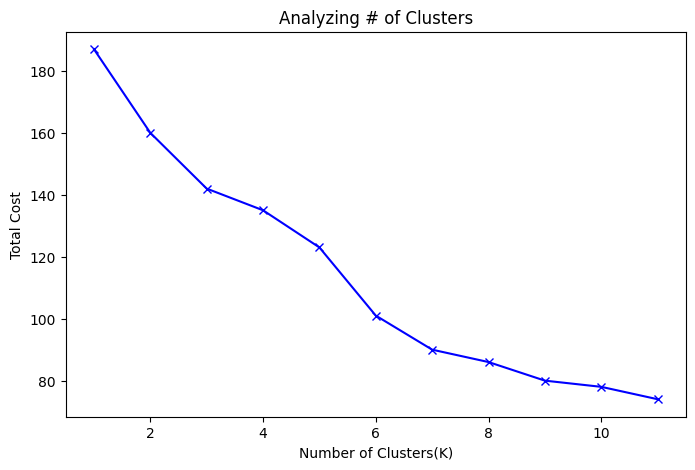

In [13]:
cost = []
for k in range(1, 12):
    kmode = KModes(n_clusters = k, init = 'Cao', n_init=5)
    kmode.fit(df_categorical)
    cost.append(kmode.cost_)
plt.figure(figsize=(8,5))
plt.plot(range(1,12), cost, 'bx-')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('Total Cost')
plt.title('Analyzing # of Clusters')
plt.show()

In [ ]:
km = KModes(n_clusters = 6, init= 'Cao',n_init=5, verbose=1)
#n_clusters depends on prev graph

df['cluster_id'] = km.fit_predict(df_categorical)
for i in range(6):
    print(df[df['cluster_id']==i]['Game'].tolist())


Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 8, cost: 101.0
Run 1, iteration: 2/100, moves: 1, cost: 101.0
['Apex Legends™', 'Delta Force', 'Marvel Rivals', 'Grand Theft Auto V Enhanced', "Tom Clancy's Rainbow Six Siege", 'War Thunder', 'Warframe', 'Overwatch', 'Geometry Dash', 'DayZ', 'Dead by Daylight', 'Euro Truck Simulator 2', 'Battlefield™ 6', 'HELLDIVERS™ 2', 'ELDEN RING', 'Call of Duty®', 'Red Dead Redemption 2', 'Street Fighter™ 6', 'R.E.P.O.', 'Monster Hunter: World', 'Rocket League®', 'Hunt: Showdown 1896', 'World of Warships']
['Limbus Company', 'Cyberpunk 2077', 'The Sims™ 4', 'BeamNG.drive']
['Counter-Strike 2', 'PUBG: BATTLEGROUNDS', 'Dota 2', 'NARAKA: BLADEPOINT', 'Team Fortress 2']
['Hearts of Iron IV', "Sid Meier's Civilization® VII", 'RimWorld', 'Mount & Blade II: Bannerlord', 'Satisfactory']
['Bongo Cat', 'VRChat', "Garry's Mo

In [ ]:
cluster_profiles = df.groupby('cluster_id')[cluster_features].mean()

# Highlight the top features for each cluster
for i in range(len(cluster_profiles)):
    top_features = cluster_profiles.loc[i].sort_values(ascending=False).head(3)
    print(f"\nCluster {i} is defined by:")
    print(top_features)

#In current form

#Cluster 0 AAA Serivce Games with Co-op, Multi, and Action
#Cluster 1 Single Player Narative Sim
#Cluster 2 Competitive f2p action multiplayer games
#Cluster 3 Single Player Strategy and System Sim Games
#Cluster 4 Casual Sandbox Games
#Cluster 5 Multiplayer RPG with Open World


Cluster 0 is defined by:
Action          0.956522
Multi-player    0.956522
Co-op           0.869565
Name: 0, dtype: float64

Cluster 1 is defined by:
Single-player    1.0
is_free          0.5
Simulation       0.5
Name: 1, dtype: float64

Cluster 2 is defined by:
is_free         1.0
Action          1.0
Multi-player    1.0
Name: 2, dtype: float64

Cluster 3 is defined by:
Simulation       1.0
Strategy         1.0
Single-player    1.0
Name: 3, dtype: float64

Cluster 4 is defined by:
Casual        1.0
Simulation    1.0
Co-op         1.0
Name: 4, dtype: float64

Cluster 5 is defined by:
RPG             1.0
Co-op           1.0
Multi-player    1.0
Name: 5, dtype: float64
